<a href="https://colab.research.google.com/github/juniorbrito777/junior-de-brito-engenharia-de-prompt-e-aplica-es-em-ia/blob/main/Aula08_automa%C3%A7%C3%A3o_de_IA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Consulta Simples a APIS Desenvolver um script que consulte uma API pública VIACEP e retorne as informações de endereço formatadas de maneira legive. Inclua o tratamento API.

Este script Python utilizará a biblioteca `requests` para fazer requisições à API do VIACEP. Ele definirá uma função para consultar um CEP, tratar possíveis erros da API (como CEP inválido ou problemas de conexão) e exibir o endereço de forma organizada.

In [7]:
import requests

def consultar_cep_viacep(cep):
    """
    Consulta a API do ViaCEP para obter informações de endereço.
    Retorna um dicionário com os dados do endereço ou None em caso de erro.
    """
    # Limpa o CEP, removendo caracteres não numéricos
    cep = str(cep).replace('-', '').replace('.', '').strip()

    # Valida se o CEP tem o formato correto (8 dígitos)
    if not cep.isdigit() or len(cep) != 8:
        print(f"Erro: CEP '{cep}' inválido. Por favor, insira um CEP com 8 dígitos numéricos.")
        return None

    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        response = requests.get(url)
        response.raise_for_status() # Lança um erro para códigos de status HTTP ruins (4xx ou 5xx)

        data = response.json()

        # Verifica se a API retornou um erro específico (ex: cep inválido)
        if 'erro' in data and data['erro']:
            print(f"Erro: CEP '{cep}' não encontrado na base de dados do ViaCEP.")
            return None

        return data

    except requests.exceptions.HTTPError as http_err:
        print(f"Erro HTTP ao consultar o CEP '{cep}': {http_err}")
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Erro de conexão ao consultar o CEP '{cep}': {conn_err}\nVerifique sua conexão com a internet.")
    except requests.exceptions.Timeout as timeout_err:
        print(f"Tempo limite excedido ao consultar o CEP '{cep}': {timeout_err}")
    except requests.exceptions.RequestException as req_err:
        print(f"Um erro inesperado ocorreu ao consultar o CEP '{cep}': {req_err}")
    except ValueError:
        print(f"Erro: Não foi possível decodificar a resposta JSON para o CEP '{cep}'.")

    return None

def formatar_endereco(endereco_data):
    """
    Formata os dados do endereço em uma string legível.
    """
    if not endereco_data:
        return "Informações de endereço não disponíveis."

    formato = f"""
    --- Detalhes do Endereço ---
    CEP:        {endereco_data.get('cep', 'N/A')}
    Logradouro: {endereco_data.get('logradouro', 'N/A')}
    Complemento: {endereco_data.get('complemento', 'N/A')}
    Bairro:     {endereco_data.get('bairro', 'N/A')}
    Cidade:     {endereco_data.get('localidade', 'N/A')}
    Estado:     {endereco_data.get('uf', 'N/A')}
    DDD:        {endereco_data.get('ddd', 'N/A')}
    """
    return formato

### Demonstração:

Agora, vamos usar a função `consultar_cep_viacep` para buscar um endereço e a `formatar_endereco` para exibi-lo de forma clara.

In [3]:
# Exemplo de uso com um CEP válido
cep_valido = '01001000' # Exemplo: Praça da Sé, São Paulo, SP
print(f"Consultando CEP: {cep_valido}")
endereco = consultar_cep_viacep(cep_valido)
print(formatar_endereco(endereco))

print("\n" + "-"*30 + "\n")

# Exemplo de uso com um CEP inválido (formato)
cep_invalido_formato = '12345'
print(f"Consultando CEP: {cep_invalido_formato}")
endereco_invalido_formato = consultar_cep_viacep(cep_invalido_formato)
print(formatar_endereco(endereco_invalido_formato))

print("\n" + "-"*30 + "\n")

# Exemplo de uso com um CEP que não existe na base (mas com formato válido)
cep_nao_existe = '99999999'
print(f"Consultando CEP: {cep_nao_existe}")
endereco_nao_existe = consultar_cep_viacep(cep_nao_existe)
print(formatar_endereco(endereco_nao_existe))

Consultando CEP: 01001000


NameError: name 'consultar_cep_viacep' is not defined

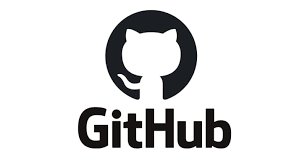